**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings('ignore')

**Importing Data**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Breast Cancer.csv to Breast Cancer.csv


In [4]:
df=pd.read_csv("Breast Cancer.csv")

# **EDA**

In [5]:
df.shape

(569, 32)

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
col_names=df.columns
col_names

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

**Drop Risk_MM variable**

In [8]:
print(df.columns)
df.drop(columns=['RISK_MM'], inplace=True, errors='ignore')

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [10]:
categorical=[var for var in df.columns if df[var].dtype=='O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :', categorical)

There are 1 categorical variables

The categorical variables are : ['diagnosis']


In [11]:
df[categorical].head()

,diagnosis
0,M
1,M
2,M
3,M
4,M


In [12]:
df[categorical].isnull().sum()

,0
diagnosis,0


In [13]:
for var in categorical:
    print(df[var].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [14]:
for var in categorical:
  print(df[var].value_counts()/float(len(df)))

diagnosis
B    0.627417
M    0.372583
Name: count, dtype: float64


In [15]:
for var in categorical:
    print(var, ' contains ', len(df[var].unique()), ' labels')

diagnosis  contains  2  labels


In [16]:
df['diagnosis'].dtypes

dtype('O')

In [17]:
print('diagnosis contains', len(df.diagnosis.unique()), 'labels')

diagnosis contains 2 labels


In [18]:
df.diagnosis.unique()

array(['M', 'B'], dtype=object)

In [19]:
df.diagnosis.value_counts()

,count
diagnosis,
B,357
M,212


In [20]:
pd.get_dummies(df.diagnosis, drop_first=True).head()

,M
0,True
1,True
2,True
3,True
4,True


**Numerical Variables**

In [21]:
numerical=[var for var in df.columns if df[var].dtype!='O']
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :', numerical)

There are 31 numerical variables

The numerical variables are : ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [22]:
df[numerical].head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [23]:
df[numerical].isnull().sum()

,0
id,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [24]:
print(round(df[numerical].describe()),2)

                id  radius_mean  texture_mean  perimeter_mean  area_mean  \
count        569.0        569.0         569.0           569.0      569.0   
mean    30371831.0         14.0          19.0            92.0      655.0   
std    125020586.0          4.0           4.0            24.0      352.0   
min         8670.0          7.0          10.0            44.0      144.0   
25%       869218.0         12.0          16.0            75.0      420.0   
50%       906024.0         13.0          19.0            86.0      551.0   
75%      8813129.0         16.0          22.0           104.0      783.0   
max    911320502.0         28.0          39.0           188.0     2501.0   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count            569.0             569.0           569.0                569.0   
mean               0.0               0.0             0.0                  0.0   
std                0.0               0.0             0.0                

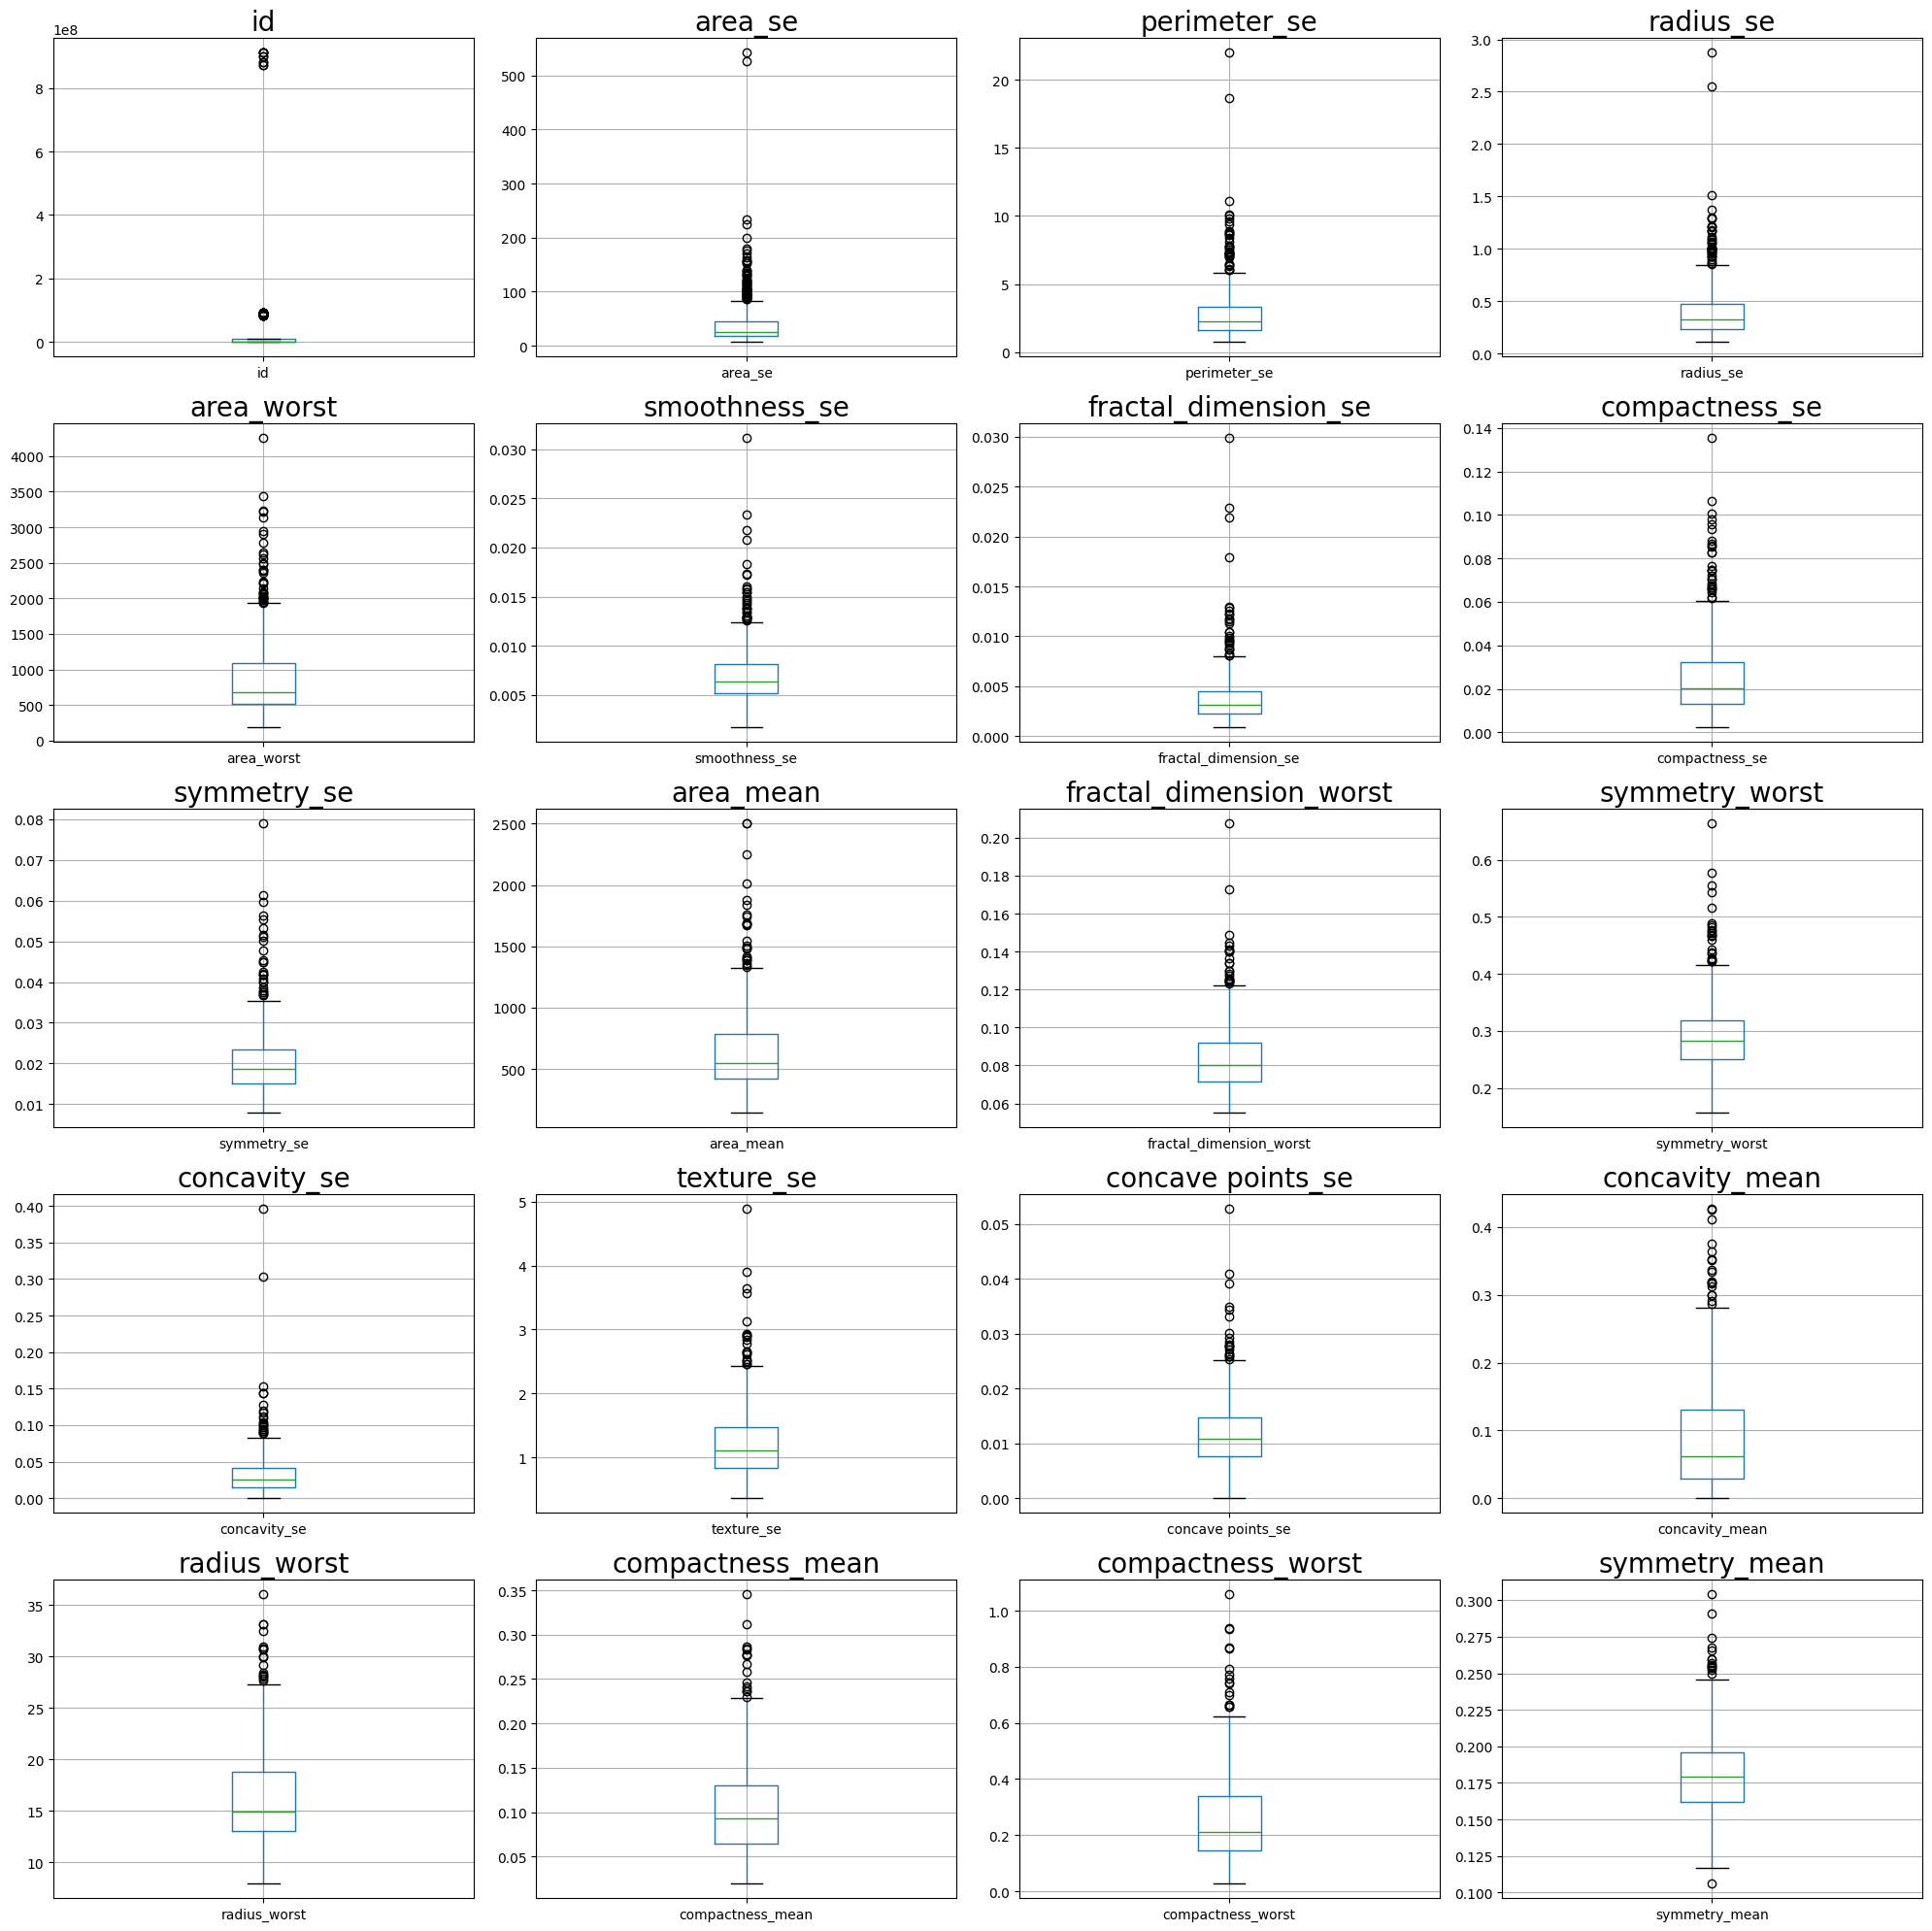

In [25]:
import matplotlib.pyplot as plt

cols=['id', 'area_se', 'perimeter_se', 'radius_se', 'area_worst', 'smoothness_se','fractal_dimension_se', 'compactness_se', 'symmetry_se',
'area_mean','fractal_dimension_worst', 'symmetry_worst', 'concavity_se', 'texture_se','concave points_se', 'concavity_mean', 'radius_worst',
'compactness_mean','compactness_worst', 'symmetry_mean']
fig, axes=plt.subplots(5, 4, figsize=(20, 20))
axes=axes.flatten()
for i, col in enumerate(cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=20)
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()


In [26]:
num_cols=df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(80, 80))
for i, col in enumerate(num_cols):
    plt.subplot(6, 6, i+
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(col, fontsize=30)
    plt.xlabel('')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

SyntaxError: '(' was never closed (ipython-input-3331310148.py, line 4)

In [ ]:
num_cols=df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    IQR=df[col].quantile(0.75)-df[col].quantile(0.25)
    Lower_fence=df[col].quantile(0.25)-(IQR*3)
    Upper_fence=df[col].quantile(0.75)+(IQR*3)
    outliers=df[(df[col] < Lower_fence) | (df[col] > Upper_fence)][col]
    print(f"{col} -> Outliers are values < {Lower_fence:.2f} or > {Upper_fence:.2f}")
    print(f"Number of outliers: {len(outliers)}\n")


In [ ]:
X=df.drop('diagnosis', axis=1)
y=df['diagnosis']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
X_train.shape, X_test.shape

In [ ]:
X_train.dtypes

In [ ]:
categorical=[col for col in X_train.columns if X_train[col].dtypes == 'O']
categorical

In [ ]:
numerical=[col for col in X_train.columns if X_train[col].dtypes != 'O']
numerical

In [ ]:
X_train[numerical].isnull().sum()

In [ ]:
X_test[numerical].isnull().sum()

In [ ]:
X_train[categorical].isnull().mean()

In [ ]:
def max_value(df, variable, top):
    return np.where(df[variable] > top, top, df[variable])
for df3 in [X_train, X_test]:
    df3['radius_mean']=max_value(df3, 'radius_mean', 25.0)
    df3['texture_mean']=max_value(df3, 'texture_mean', 30.0)
    df3['perimeter_mean']=max_value(df3, 'perimeter_mean', 180.0)
    df3['area_mean']=max_value(df3, 'area_mean', 2000.0)
    df3['smoothness_mean']=max_value(df3, 'smoothness_mean', 0.15)


In [ ]:
X_train.radius_mean.max(), X_test.radius_mean.max()

In [ ]:
X_train.texture_mean.max(), X_test.texture_mean.max()

In [ ]:
X_train.perimeter_mean.max(), X_test.perimeter_mean.max()

In [ ]:
X_train.area_mean.max(), X_test.area_mean.max()

In [ ]:
X_train.smoothness_mean.max(), X_test.smoothness_mean.max()

In [ ]:
X_train[numerical].describe()

In [ ]:
X_train.describe()

In [ ]:
cols=X_train.columns

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
X_train=pd.DataFrame(X_train, columns=[cols])
X_test=pd.DataFrame(X_test, columns=[cols])

In [ ]:
X_train.describe()

# **MODEL TRAINING**

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(solver='liblinear', random_state=0)
logreg.fit(X_train, y_train)

**Predict Result**

In [ ]:
y_pred_test=logreg.predict(X_test)
y_pred_test

In [ ]:
logreg.predict_proba(X_test)[:,0]

In [ ]:
logreg.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

In [ ]:
y_pred_train=logreg.predict(X_train)
y_pred_train

In [ ]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

**Overfitting and Underfitting**

In [ ]:
print('Training set score: {:.4f}'.format(logreg.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(logreg.score(X_test, y_test)))

In [ ]:
logreg100=LogisticRegression(C=100, solver='liblinear', random_state=0)
logreg100.fit(X_train, y_train)

In [ ]:
print('Training set score: {:.4f}'.format(logreg100.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(logreg100.score(X_test, y_test)))

In [ ]:
logreg001=LogisticRegression(C=0.01, solver='liblinear', random_state=0)
logreg001.fit(X_train, y_train)

In [ ]:
print('Training set score: {:.4f}'.format(logreg001.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(logreg001.score(X_test, y_test)))

In [ ]:
y_test.value_counts()

In [ ]:
null_accuracy=(67/(67+47))
print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred_test)
print('Confusion matrix\n\n', cm)
print('\nTrue Positives(TP)=', cm[0,0])
print('\nTrue Negatives(TN)=', cm[1,1])
print('\nFalse Positives(FP)=', cm[0,1])
print('\nFalse Negatives(FN)=', cm[1,0])

In [27]:
cm_matrix=pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], index=['Predict Positive:1', 'Predict Negative:0'])
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

NameError: name 'cm' is not defined

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

In [ ]:
TP=cm[0,0]
TN=cm[1,1]
FP=cm[0,1]
FN=cm[1,0]

In [ ]:
classification_accuracy=(TP+TN)/float(TP+TN+FP+FN)
print('Classification accuracy:{0:0.4f}'.format(classification_accuracy))

In [ ]:
classification_error=(FP+FN)/float(TP+TN+FP+FN)
print('Classification error:{0:0.4f}'.format(classification_error))

**Precision**

In [ ]:
precision=TP/float(TP+FP)
print('Precision:{0:0.4f}'.format(precision))

**Recall**

In [ ]:
recall=TP/float(TP+FN)
print('Recall or Sensitivity:{0:0.4f}'.format(recall))

In [ ]:
true_positive_rate=TP/float(TP+FN)
print('True Positive Rate:{0:0.4f}'.format(true_positive_rate))

In [ ]:
false_positive_rate=FP/float(FP+TN)
print('False Positive Rate:{0:0.4f}'.format(false_positive_rate))

**Specificity**

In [ ]:
specificity=TN/(TN+FP)
print('Specificity:{0:0.4f}'.format(specificity))

**Adjusting Threshold level**

In [ ]:
y_pred_prob=logreg.predict_proba(X_test)[0:10]
y_pred_prob

In [ ]:
y_pred_prob_df=pd.DataFrame(data=y_pred_prob, columns=['Prob of-diagnosis(M)', 'Prob of-diagonosis (B)'])
y_pred_prob_df

In [ ]:
logreg.predict_proba(X_test)[0:10, 1]

In [ ]:
y_pred1=logreg.predict_proba(X_test)[:, 1]

In [ ]:
plt.rcParams['font.size']=12
plt.hist(y_pred1, bins=10)
plt.title('Histogram of predicted diagonosis')
plt.xlim(0,1)
plt.xlabel('Predicted diagonosis')
plt.ylabel('Frequency')


In [ ]:
from sklearn.preprocessing import binarize
from sklearn.metrics import confusion_matrix, accuracy_score
y_test_numeric=np.where(y_test == 'Yes', 1, 0) if y_test.dtype == 'O' else y_test
for i in range(1,5):
    y_pred_prob=logreg.predict_proba(X_test)[:,1].reshape(-1,1)
    y_pred_bin=binarize(y_pred_prob, threshold=i/10)
    y_pred_label=np.where(y_pred_bin==1, 1, 0)
    cm=confusion_matrix(y_test_numeric, y_pred_label)
    print(f"With threshold {i/10} the Confusion Matrix is:\n{cm}\n")
    print(f"Correct predictions: {cm[0,0]+cm[1,1]}")
    print(f"Type I errors (False Positives): {cm[0,1]}")
    print(f"Type II errors (False Negatives): {cm[1,0]}")
    print(f"Accuracy: {accuracy_score(y_test_numeric, y_pred_label):.4f}")
    print(f"Sensitivity: {cm[1,1]/(cm[1,1]+cm[1,0]):.4f}")
    print(f"Specificity: {cm[0,0]/(cm[0,0]+cm[0,1]):.4f}")
    print("====================================================\n")


**ROC**

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds=roc_curve(y_test, y_pred1, pos_label='Yes')
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], 'k--' )
plt.rcParams['font.size']=12
plt.title('ROC curve for diagonosis')
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
ROC_AUC=roc_auc_score(y_test, y_pred1)
print('ROC AUC:{:.4f}'.format(ROC_AUC))

In [ ]:
from sklearn.model_selection import cross_val_score
Cross_validated_ROC_AUC=cross_val_score(logreg, X_train, y_train, cv=5, scoring='roc_auc').mean()
print('Cross validated ROC AUC:{:.4f}'.format(Cross_validated_ROC_AUC))

**Recursive Feature Elimination with Cross Validation**

In [ ]:
from sklearn.feature_selection import RFECV
rfecv=RFECV(estimator=logreg, step=1, cv=5, scoring='accuracy')
rfecv=rfecv.fit(X_train, y_train)

In [ ]:
print("Optimal number of features:%d" % rfecv.n_features_)

In [ ]:
X_train_rfecv=rfecv.transform(X_train)
logreg.fit(X_train_rfecv, y_train)

In [ ]:
X_test_rfecv=rfecv.transform(X_test)
y_pred_rfecv=logreg.predict(X_test_rfecv)

In [ ]:
print ("Classifier score: {:.4f}".format(logreg.score(X_test_rfecv,y_test)))

In [ ]:
from sklearn.metrics import confusion_matrix
cm1=confusion_matrix(y_test, y_pred_rfecv)
print('Confusion matrix\n\n', cm1)
print('\nTrue Positives(TP1)=', cm1[0,0])
print('\nTrue Negatives(TN1)=', cm1[1,1])
print('\nFalse Positives(FP1)=', cm1[0,1])
print('\nFalse Negatives(FN1)=', cm1[1,0])

**k-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')
print('Cross-validation scores:{}'.format(scores))

In [ ]:
print('Average cross-validation score: {:.4f}'.format(scores.mean()))

**Hyperparameter Optimization using GridSearch CV**

In [ ]:
from sklearn.model_selection import GridSearchCV
parameters=[{'penalty':['l1','l2']},
              {'C':[1, 10, 100, 1000]}]
grid_search=GridSearchCV(estimator=logreg,param_grid=parameters,scoring='accuracy',
cv=5,verbose=0)
grid_search.fit(X_train, y_train)

In [ ]:
print('GridSearch CV best score:{:.4f}\n\n'.format(grid_search.best_score_))
print('Parameters that give the best results :','\n\n', (grid_search.best_params_))
print('\n\nEstimator that was chosen by the search :','\n\n', (grid_search.best_estimator_))

In [ ]:
print('GridSearch CV score on test set: {0:0.4f}'.format(grid_search.score(X_test, y_test)))